In [7]:
import os
from dotenv import load_dotenv

In [8]:
load_dotenv('./.env')
pinecone_env = os.environ.get('PINECONE_ENV')

In [9]:
pinecone_env

'gcp-starter'

### LangChain primeiros passos

In [11]:
from langchain_openai import OpenAI
llm = OpenAI(model_name='davinci-002', temperature=0.7, max_tokens=512)
print(llm)

OpenAI
Params: {'model_name': 'davinci-002', 'temperature': 0.7, 'top_p': 1, 'frequency_penalty': 0, 'presence_penalty': 0, 'n': 1, 'logit_bias': {}, 'seed': None, 'logprobs': None, 'max_tokens': 512}


In [12]:
output = llm('explique como funções python funcionam')

In [13]:
print(output)

. Enquanto eles são muito parecidos com funções Java, Python é interpretado em vez de compilada, e é muito mais fácil entender o que está acontecendo por trás dos bastidores. 04/12/2019 · Como Usar o Python Usando o IDLE. Você pode usar o IDLE para programar usando o Python. Ele é um ambiente de desenvolvimento de código aberto que pode ser usado tanto no Windows quanto no Mac. O IDLE permite criar arquivos de código, ex. 03/12/2019 · Como Usar o IDLE no Windows. O IDLE é um dos ambientes de desenvolvimento integrado da Python. Nele, você pode escrever, executar e depurar seu código. O IDLE é um aplicativo bastante simples de usar e muito útil para programadores iniciantes. 17/12/2019 · Como Usar a Linguagem de Programação Python. A Python é uma linguagem de programação leve, flexível e dinâmica que pode ser usada para uma variedade de tarefas, incluindo desenvolvimento de aplicativos, web, ciência de dados e análise de.

Para usar Python você precisa de um editor ou IDE Integrated Dev

In [14]:
print(llm.get_num_tokens('explique como funções python funcionam'))

8


In [15]:
output = llm.generate(['... é a capital da França', 
                       'qual é a formula da área de um círculo?'])

In [16]:
print(output.generations)

[[Generation(text='\n\nÉ a capital da\n\nFrança! Onde fica?\n\nFrança! Onde fica?\n\nA França fica na Europa.\n\nA França fica na Europa.\n\nA França é o segundo país mais\n\npopuloso da Europa.\n\nA França é o segundo país mais\n\npopuloso da Europa.\n\nParis é a capital da França e\n\ntambém a sua cidade mais\n\npopulosa.\n\nParis é a capital da França e\n\ntambém a sua cidade mais\n\npopulosa.\n\nParis tem mais de 2 milhões de\n\nhabitantes e foi fundada no século III\n\nA.C.\n\nParis tem mais de 2 milhões de\n\nhabitantes e foi fundada no século III\n\nA.C.\n\nParis é a única cidade do mundo\n\nque tem um monumento que pode ser\n\nvisto do espaço: a Torre Eiffel.\n\nParis é a única cidade do mundo\n\nque tem um monumento que pode ser\n\nvisto do espaço: a Torre Eiffel.\n\nParis é uma cidade muito\n\nimportante, mas é muito cara também.\n\nParis é uma cidade muito\n\nimportante, mas é muito cara também.\n\nO Louvre é um dos museus mais\n\nimportantes do mundo e uma das\n\nmaravilhas

In [17]:
output.generations[0][0].text

'\n\nÉ a capital da\n\nFrança! Onde fica?\n\nFrança! Onde fica?\n\nA França fica na Europa.\n\nA França fica na Europa.\n\nA França é o segundo país mais\n\npopuloso da Europa.\n\nA França é o segundo país mais\n\npopuloso da Europa.\n\nParis é a capital da França e\n\ntambém a sua cidade mais\n\npopulosa.\n\nParis é a capital da França e\n\ntambém a sua cidade mais\n\npopulosa.\n\nParis tem mais de 2 milhões de\n\nhabitantes e foi fundada no século III\n\nA.C.\n\nParis tem mais de 2 milhões de\n\nhabitantes e foi fundada no século III\n\nA.C.\n\nParis é a única cidade do mundo\n\nque tem um monumento que pode ser\n\nvisto do espaço: a Torre Eiffel.\n\nParis é a única cidade do mundo\n\nque tem um monumento que pode ser\n\nvisto do espaço: a Torre Eiffel.\n\nParis é uma cidade muito\n\nimportante, mas é muito cara também.\n\nParis é uma cidade muito\n\nimportante, mas é muito cara também.\n\nO Louvre é um dos museus mais\n\nimportantes do mundo e uma das\n\nmaravilhas da França.\n\nO L

In [22]:
output = llm.generate(['Escreva um slogan original para um restaurante de sushi!'] * 3)

In [23]:
for o in output.generations:
    print(o[0].text, end='')

 Confira essas ideias bem criativas e com certeza você irá gostar de muitas delas.

Slogans são frases curta e objetiva que expressa o motivo de existir de uma empresa. Para restaurantes, é a maneira de se diferenciar, de se comunicar com o seu público-alvo e de chamar a atenção de novos clientes.

Hoje, o slogan é uma excelente ferramenta de marketing e de publicidade. Através dele, os restaurantes conseguem se comunicar com seus clientes, fixar a marca na mente das pessoas e conseguir novos clientes.

Quando se trata de um restaurante especializado em comida japonesa, o slogan ideal precisa ser criativo, inovador e que tenha ligações com a cultura oriental.

Confira algumas ideias de slogans para restaurantes de sushi.

Slogans para restaurantes de sushi

– Sushi é vida!

– Tão bom quanto o sushi é comer e ver quem come.

– O melhor lugar para comer sushi.

– O melhor sushi de São Paulo.

– O melhor sushi da cidade.

– Caia na rede!

– A intensa e exótica sensação do sushi.

– Sushi 

### ChatModels: GPT-3.5 Turbo e GPT-4

In [9]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

In [10]:
load_dotenv('./.env')
openai_apikey = os.environ.get('OPENAI_API_KEY')

In [11]:
chat = ChatOpenAI(
    model="gpt-3.5-turbo",
    temperature=0.5,
    max_tokens=1024,
    timeout=None,
    max_retries=1,
    api_key=openai_apikey,  # if you prefer to pass api key in directly instaed of using env vars
    # base_url="...",
    # organization="...",
    # other params...
)

messages = [
    (
        "system",
        "Você é um especialista em machine learning que responde tudo em português.",
    ),
    (
        "human", 
        "Explique em um parágrafo o que é machine learning."
    ),
]

output = chat.invoke(messages)

In [12]:
print(output.content)

Machine learning, ou aprendizado de máquina, é uma subárea da inteligência artificial que se concentra no desenvolvimento de algoritmos e modelos que permitem aos computadores aprender padrões e tomar decisões com base em dados, sem a necessidade de serem explicitamente programados. O processo de aprendizado ocorre a partir da análise de grandes quantidades de dados, permitindo que a máquina identifique padrões e tendências, e seja capaz de fazer previsões ou tomar decisões com base nesses insights. O objetivo final do machine learning é criar sistemas capazes de aprender e se aprimorar continuamente, melhorando seu desempenho e precisão ao longo do tempo.


### Prompt Templates

In [14]:
from langchain_core.prompts import PromptTemplate

In [15]:
template = """ 
Você é um virologista experiente.
Escreva algumas frases sobre o sequinte {virus} e {idioma}.
"""

prompt = PromptTemplate.from_template(template=template)

In [16]:
print(prompt)

input_variables=['idioma', 'virus'] input_types={} partial_variables={} template=' \nVocê é um virologista experiente.\nEscreva algumas frases sobre o sequinte {virus} e {idioma}.\n'


In [24]:
from langchain_openai import OpenAI
llm = OpenAI(model_name='davinci-002', temperature=0.7, max_tokens=512)
output = llm(prompt.format(virus="ebola", idioma="português"))
print(output)

A: O vírus da ebola causa febre hemorrágica, dor de garganta e dores musculares intensas.
A doença foi identificada pela primeira vez em 1976, na República Democrática do Congo, e é transmitida através de contato com partes do corpo de pessoas ou animais doentes.
O vírus do ebola é transmitido aos humanos através do contato com a saliva, sangue, urina, fezes, secreções vaginais, ou outras partes do corpo de animais infectados.
A ocorrência da doença entre humanos é considerada um evento de emergência de saúde pública de importância internacional.



### Simple Chains

In [36]:
from langchain_openai.chat_models import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from langchain.chains import LLMChain

llm = ChatOpenAI(model_name="gpt-4", temperature=0.5)

template = """ 
Você é um virologista experiente.
Escreva um resumo sobre o sequinte {virus} em {idioma}.
"""

prompt = PromptTemplate.from_template(template=template)

chain = LLMChain(llm=llm, prompt=prompt)

output = chain.run({'virus': 'HIV', 'idioma': 'english'})

print(output)

HIV, or Human Immunodeficiency Virus, is a retrovirus that attacks the immune system, specifically CD4 cells (T cells), which are crucial for fighting off infections. Over time, HIV can destroy so many of these cells that the body can't fight off infections and disease, leading to the final stage of HIV infection, AIDS (Acquired Immunodeficiency Syndrome). HIV is transmitted through certain body fluids like blood, semen, vaginal and rectal fluids, and breast milk. Unprotected sex, sharing injection drug equipment, and mother-to-child transmission during birth or breastfeeding are the primary ways HIV is spread. Currently, there is no effective cure for HIV, but it can be controlled through antiretroviral therapy (ART). Regular use of ART can keep the virus suppressed at very low levels in the body, prolonging life and greatly reducing the risk of transmitting HIV to others. Despite significant global efforts, HIV remains a major public health issue, having claimed more than 32 million 

### Sequential Chains

In [11]:
import os
from dotenv import load_dotenv
from langchain_openai.chat_models import ChatOpenAI
from langchain_openai import OpenAI
from langchain_core.prompts import PromptTemplate
from langchain.chains import LLMChain, SimpleSequentialChain

load_dotenv('./.env')
openai_apikey = os.environ.get('OPENAI_API_KEY')

llm1 = OpenAI(model_name='davinci-002', temperature=0.7, max_tokens=512)

template1 = """Você é um cientista experiente e programador Python.
Escreva um código em que implementa o conceito de {conceito}."""

prompt1 = PromptTemplate.from_template(template=template1)

chain1 = LLMChain(llm=llm1, prompt=prompt1)

#------------ segunda chain --------------#

llm2 = ChatOpenAI(
    model="gpt-3.5-turbo",
    temperature=1.2,
    max_tokens=1024,
    timeout=None,
    max_retries=1,
    api_key=openai_apikey
)

template2 = """Dada a função {function} Python, descreva como funciona da forma mais detalhada possível."""

prompt2 = PromptTemplate.from_template(template=template2)

chain2 = LLMChain(llm=llm2, prompt=prompt2)

overall_chain = SimpleSequentialChain(chains=[chain1, chain2], verbose=True)
output = overall_chain.run("regressão linear")

print(output)




> Entering new SimpleSequentialChain chain...
 O código deve permitir que você insira os valores de x e y e produza o valor estimado de y, após o cálculo de uma reta que best fit os pontos dados.

Como parte de um projeto de pesquisa você está desenvolvendo um software de análise de dados. O software irá usar técnicas de regressão linear para calcular a quantidade de água que um determinado lençol freático pode fornecer. Pelo fato de que você tem vários sensores instalados em diferentes pontos do lençol, você tem informações sobre a umidade do solo em cada um desses pontos. A uma profundidade de 5 metros, a umidade é 17% em um ponto, 18% em outro ponto, 23% em outro ponto e assim por diante. Escreva um código que irá retornar a quantidade de água que um determinado lençol freático pode fornecer.

##  4\. Imagens

Use os dados de imagens abaixo para implementar o conceito de clusterização.

Os dados são oriundos do projeto Kaggle [Kaggle: Kia World Championship 2012](www.kaggle.com/c/

### Openai x calculos complexos

In [19]:
# Exemplo exponenciação

resultado = 5.1 ** 7.3

print(resultado)

# ---------------- OpenAI -----------------#

import os
from dotenv import load_dotenv
from langchain_openai.chat_models import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from langchain.chains import LLMChain

load_dotenv('./.env')
openai_apikey = os.environ.get('OPENAI_API_KEY')

chat = ChatOpenAI(
    model="gpt-3.5-turbo",
    temperature=0.5,
    max_tokens=1024,
    timeout=None,
    max_retries=1,
    api_key=openai_apikey,
)

template = """Qual é a resposta para {X} elevado à potência de {Y}?"""

prompt = PromptTemplate.from_template(template=template)

chain = LLMChain(llm=chat, prompt=prompt)

output = chain.run({"X": "5.1", "Y": "7.3"})

print(output)

146306.05007233328
A resposta para 5.1 elevado à potência de 7.3 é aproximadamente 17,820.


### LangChain Agents

In [2]:
import os
from dotenv import load_dotenv
from langchain_experimental.agents.agent_toolkits import create_python_agent
from langchain_experimental.tools.python.tool import PythonAstREPLTool
from langchain_openai import OpenAI

load_dotenv('./.env')
openai_apikey = os.environ.get('OPENAI_API_KEY')

llm = OpenAI(temperature=0)

agent_executor = create_python_agent(
    llm=llm,
    tool=PythonAstREPLTool(),
    verbose=True
)

agent_executor.run('qual a resposta para 5.1 elevado à potência de7.3')




> Entering new AgentExecutor chain...
 I should use the python_repl_ast to calculate the power of 5.1 to the power of 7.3
Action: python_repl_ast
Action Input: 5.1 ** 7.3
Observation: 146306.05007233328
Thought: I now know the final answer
Final Answer: 146306.05007233328

> Finished chain.


'146306.05007233328'

In [24]:
5.1 ** 7.3

146306.05007233328

### Splitting e Embedding de texto

In [44]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

with open(file='docs/CLT.txt', encoding="utf8") as f:
    clt = f.read()

# Em length_function estou passando um contador de caracteres apenas para testes, mas o ideal seria um contador de tokens
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=10,
    length_function=len
)

In [45]:
chunks = text_splitter.create_documents([clt])

In [46]:
print(chunks)

[Document(metadata={}, page_content='CLT E A REFORMA TRABALHISTA: EVOLUÇÃO\n                                     NAS RELAÇÕES DE TRABALHO\n\n                                                                                                Eliezer de Queiroz Noleto1'), Document(metadata={}, page_content='Ao falarmos sobre a Consolidação das Leis do Trabalho (CLT), somos reme-\n          tidos ao período conhecido como Era Vargas. Editada no ano de 1943, a CLT resultou\n          da coletânea de inúmeras leis esparsas então existentes que disciplinavam aspectos\n          sobre direito individual do trabalho, direito coletivo, fiscalização do trabalho, direito\n          processual do trabalho, além de legislações específicas de determinadas profissões.\n                    Esse era o espírito do trabalho desenvolvido pela comissão constituída\n          para elaborar a CLT, evidenciado na exposição de motivos que acompanhou o\n          texto final do projeto. Segundo esse escrito, a cons

In [47]:
print(chunks[0])

page_content='CLT E A REFORMA TRABALHISTA: EVOLUÇÃO
                                     NAS RELAÇÕES DE TRABALHO

                                                                                                Eliezer de Queiroz Noleto1'


In [48]:
print(chunks[1])

page_content='Ao falarmos sobre a Consolidação das Leis do Trabalho (CLT), somos reme-
          tidos ao período conhecido como Era Vargas. Editada no ano de 1943, a CLT resultou
          da coletânea de inúmeras leis esparsas então existentes que disciplinavam aspectos
          sobre direito individual do trabalho, direito coletivo, fiscalização do trabalho, direito
          processual do trabalho, além de legislações específicas de determinadas profissões.
                    Esse era o espírito do trabalho desenvolvido pela comissão constituída
          para elaborar a CLT, evidenciado na exposição de motivos que acompanhou o
          texto final do projeto. Segundo esse escrito, a consolidação nada mais é do que “a
          fase própria da concatenação dos textos e da coordenação dos princípios, quando
          já se denuncia primeiro o pensamento do sistema depois de haverem sido regu-'


In [49]:
chunks[1].page_content

'Ao falarmos sobre a Consolidação das Leis do Trabalho (CLT), somos reme-\n          tidos ao período conhecido como Era Vargas. Editada no ano de 1943, a CLT resultou\n          da coletânea de inúmeras leis esparsas então existentes que disciplinavam aspectos\n          sobre direito individual do trabalho, direito coletivo, fiscalização do trabalho, direito\n          processual do trabalho, além de legislações específicas de determinadas profissões.\n                    Esse era o espírito do trabalho desenvolvido pela comissão constituída\n          para elaborar a CLT, evidenciado na exposição de motivos que acompanhou o\n          texto final do projeto. Segundo esse escrito, a consolidação nada mais é do que “a\n          fase própria da concatenação dos textos e da coordenação dos princípios, quando\n          já se denuncia primeiro o pensamento do sistema depois de haverem sido regu-'

In [50]:
len(chunks)

1167

In [55]:
def embedding_cost(texts):
    import tiktoken
    enc = tiktoken.encoding_for_model('text-embedding-3-small')
    qtd_tokens = [len(enc.encode(page.page_content)) for page in texts]
    total_tokens = sum(qtd_tokens)
    print(f'Total de tokens: {total_tokens}')
    print(f'Custo de Embedding em USD: {total_tokens / 1000 * 0.0020:.6f}')

In [56]:
embedding_cost(chunks)

Total de tokens: 257483
Custo de Embedding em USD: 0.514966


In [54]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings()

In [57]:
vector = embeddings.embed_query("workshop de llm")

In [58]:
vector

[-0.022120870649814606,
 0.00631162291392684,
 -0.013944531790912151,
 -0.011898670345544815,
 -0.04620235785841942,
 0.01656579039990902,
 -0.029693398624658585,
 0.01839854195713997,
 0.0002273178834002465,
 -0.00875173881649971,
 0.016665242612361908,
 -0.005143066868185997,
 0.011103058233857155,
 0.013944531790912151,
 -0.010570281185209751,
 0.00995936430990696,
 0.005828572437167168,
 -0.013695902191102505,
 0.019535129889845848,
 -0.019691411405801773,
 0.003317420370876789,
 0.008083992637693882,
 0.007615149021148682,
 -0.01943567954003811,
 -5.732894715038128e-05,
 -0.03168242797255516,
 0.01551444549113512,
 -0.01186315156519413,
 -0.003278349991887808,
 -0.0008963961154222488,
 0.0152871273458004,
 0.015954874455928802,
 -0.011642937548458576,
 -0.015031394548714161,
 0.002406372921541333,
 -0.019904522225260735,
 0.002168399514630437,
 0.008382346481084824,
 0.020728548988699913,
 0.011032020673155785,
 0.009888327680528164,
 0.004137896001338959,
 0.003970959223806858,
 

In [59]:
embeddings.embed_query(chunks[0].page_content)

[-0.013210078701376915,
 -0.017698809504508972,
 0.007723852060735226,
 -0.027768123894929886,
 -0.01624300517141819,
 0.018022321164608,
 -0.011289224959909916,
 0.0009174601873382926,
 -0.020152108743786812,
 -0.011343143880367279,
 -0.004364043939858675,
 0.007454258855432272,
 0.00986711960285902,
 0.006143360398709774,
 -0.0007519129430875182,
 0.013311176560819149,
 0.013304436579346657,
 -0.013769485056400299,
 -0.003989982884377241,
 -0.017294419929385185,
 -0.010729818604886532,
 -0.00034373163362033665,
 0.0034575359895825386,
 -0.008835924789309502,
 0.005647982470691204,
 -0.015151151455938816,
 0.005240222439169884,
 -0.026110123842954636,
 0.02798379957675934,
 -0.005809738766402006,
 0.00985364057123661,
 0.0151646314188838,
 -0.019195053726434708,
 -0.02434428781270981,
 -0.03154243156313896,
 -0.03340262547135353,
 -0.008775266818702221,
 0.005246962420642376,
 0.007636234164237976,
 0.0011803137604147196,
 0.02698630280792713,
 -0.033240869641304016,
 -0.0023454630281

## Conectando ao Pinecone

In [ ]:
import os
from pinecone import Pinecone, ServerlessSpec
from langchain.vectorstores import Pinecone as pc
from dotenv import load_dotenv

load_dotenv('./.env')
pinecone_api_key = os.environ.get('PINECONE_API_KEY')
pinecone_env = os.environ.get('PINECONE_ENV')

pine = Pinecone(api_key=os.environ.get("PINECONE_API_KEY"))

### Exibindo os Indexes existentes

In [60]:
indexes = pine.list_indexes()
print(indexes)

{'indexes': [{'deletion_protection': 'disabled',
              'dimension': 1536,
              'host': 'linuxtips-gjjw9fq.svc.aped-4627-b74a.pinecone.io',
              'metric': 'cosine',
              'name': 'linuxtips',
              'spec': {'serverless': {'cloud': 'aws', 'region': 'us-east-1'}},
              'status': {'ready': True, 'state': 'Ready'}}]}


## Deletando um Index

In [62]:
pine.delete_index('linuxtips')
indexes = pine.list_indexes()
print(indexes)

{'indexes': []}


## Criando um Index

In [66]:
import time

index_name = 'linuxtips'
indexes = pine.list_indexes()

"""
if (len(indexes) == 0):
  pine.create_index(
    name=index_name, 
    dimension=1536, 
    metric='cosine', 
    spec=ServerlessSpec(
            cloud='aws', 
            region='us-east-1')
  )
  print('Feito!')
"""

if (len(indexes) == 0):
    pine.create_index(
        name=index_name,
        dimension=1536,
        metric="cosine",
        spec=ServerlessSpec(
            cloud='aws', 
            region='us-east-1'
        ) 
    ) 

# Wait for the index to be ready
while not pine.describe_index(index_name).status['ready']:
    time.sleep(1)

### Prepando atributos para o Pinecone

In [67]:
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings

with open(file='docs/CLT.txt', encoding="utf8") as f:
    clt = f.read()

# Em length_function estou passando um contador de caracteres apenas para testes, mas o ideal seria um contador de tokens
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=10,
    length_function=len
)

embeddings = OpenAIEmbeddings()
chunks = text_splitter.create_documents([clt])

vector_store = pc.from_texts(
    texts=[text.page_content for text in chunks], 
    embedding=embeddings, 
    index_name=index_name
)


### Conversando com os dados (similarity search)

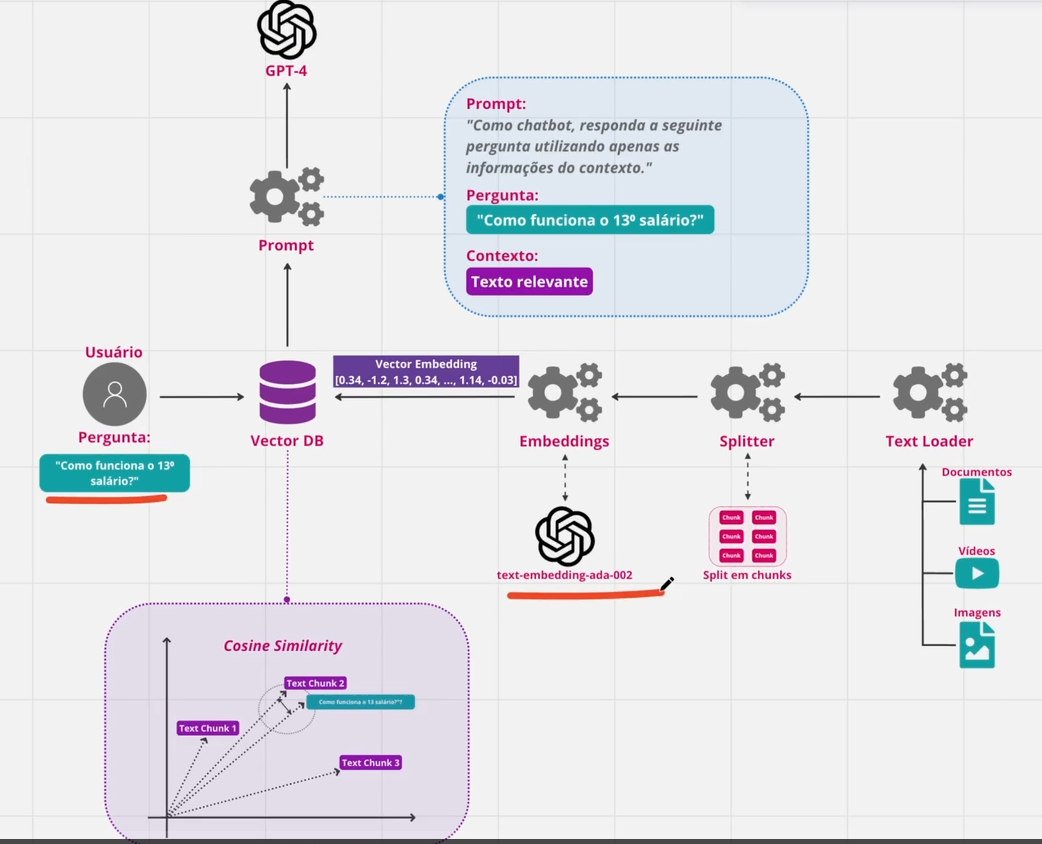

In [68]:
query = 'explique a remuneraçãop das férias'
result = vector_store.similarity_search(query)

print(result)

[Document(metadata={}, page_content='tativos da respectiva categoria profissional, e pro-         da remuneração da tarefa na data da concessão\nvidenciará a afixação de aviso nos locais de tra-            das férias. (Parágrafo acrescido pelo Decreto-Lei nº 1.535,\nbalho. (Parágrafo acrescido pelo Decreto-Lei nº 1.535, de   de 13/4/1977)\n13/4/1977)                                                    § 3º Quando o salário for pago por percenta-\nArt. 140. Os empregados contratados há menos                gem, comissão ou viagem, apurar-se-á a média\nde 12 (doze) meses gozarão, na oportunidade,                percebida pelo empregado nos 12 (doze) meses\nférias proporcionais, iniciando-se, então, novo             que precederem à concessão das férias. (Parágrafo\nperíodo aquisitivo. (Artigo com redação dada pelo           acrescido pelo Decreto-Lei nº 1.535, de 13/4/1977)\nDecreto-Lei nº 1.535, de 13/4/1977)                           § 4º A parte do salário paga em utilidades será'), Do

In [69]:
for r in result:
    print(r.page_content)
    print('-' * 50)

tativos da respectiva categoria profissional, e pro-         da remuneração da tarefa na data da concessão
videnciará a afixação de aviso nos locais de tra-            das férias. (Parágrafo acrescido pelo Decreto-Lei nº 1.535,
balho. (Parágrafo acrescido pelo Decreto-Lei nº 1.535, de   de 13/4/1977)
13/4/1977)                                                    § 3º Quando o salário for pago por percenta-
Art. 140. Os empregados contratados há menos                gem, comissão ou viagem, apurar-se-á a média
de 12 (doze) meses gozarão, na oportunidade,                percebida pelo empregado nos 12 (doze) meses
férias proporcionais, iniciando-se, então, novo             que precederem à concessão das férias. (Parágrafo
período aquisitivo. (Artigo com redação dada pelo           acrescido pelo Decreto-Lei nº 1.535, de 13/4/1977)
Decreto-Lei nº 1.535, de 13/4/1977)                           § 4º A parte do salário paga em utilidades será
--------------------------------------------------

### Gerando respostas com LLM

In [74]:
from langchain_openai.chat_models import ChatOpenAI
from langchain.chains import RetrievalQA
from dotenv import load_dotenv
import os

load_dotenv('./.env')
openai_apikey = os.environ.get('OPENAI_API_KEY')

llm = ChatOpenAI(
    model="gpt-3.5-turbo-16k",
    temperature=0.5,
    api_key=openai_apikey
)

retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k': 3})

chain = RetrievalQA.from_chain_type(llm=llm, chain_type='stuff', retriever= retriever)

In [75]:
query = 'explique a remuneração das férias'
resp = chain.run(query)

print(resp)

C:\Users\renaf\AppData\Local\Temp\ipykernel_21412\1553248607.py:2: LangChainDeprecationWarning: The method `Chain.run` was deprecated in langchain 0.1.0 and will be removed in 1.0. Use :meth:`~invoke` instead.
  resp = chain.run(query)


A remuneração das férias é o valor que o empregado recebe durante o período de descanso. De acordo com a legislação trabalhista brasileira, o empregado tem direito a receber a remuneração das férias acrescida de um terço do valor do salário. 

Para calcular a remuneração das férias, é levado em consideração o salário que o empregado recebe no momento da concessão das férias. Caso o salário seja fixo, a remuneração será o valor integral do salário mais um terço. 

No caso de salários variáveis, como comissões, percentagens ou viagens, a remuneração das férias será calculada com base na média das comissões, percentagens ou viagens recebidas nos últimos 12 meses que antecedem a concessão das férias. 

É importante ressaltar que a remuneração das férias não deve sofrer descontos referentes a faltas do empregado ao serviço. Além disso, o período das férias é considerado como tempo de serviço para todos os efeitos legais.


In [76]:
query = 'como funciona o décimo terceiro salário?'
resp = chain.run(query)

print(resp)

O décimo terceiro salário é um benefício garantido aos trabalhadores no Brasil. Ele consiste no pagamento de um salário adicional, equivalente a 1/12 avos da remuneração devida em dezembro, por mês trabalhado no ano. O valor do décimo terceiro salário pode variar de acordo com o salário base, horas extras, comissões e demais adicionais que o trabalhador tenha direito.

Esse pagamento é obrigatório e deve ser realizado em duas parcelas. A primeira parcela deve ser paga até o dia 30 de novembro e corresponde a 50% do valor do décimo terceiro salário. Já a segunda parcela deve ser paga até o dia 20 de dezembro e corresponde aos 50% restantes.

É importante ressaltar que o décimo terceiro salário não sofre descontos de imposto de renda até o valor de R$ 1.903,98. Acima desse valor, há a incidência do imposto de renda de acordo com a tabela progressiva.

Cabe destacar que o décimo terceiro salário também é devido aos empregados domésticos, sendo calculado de forma proporcional ao tempo de s